# Multi-Terrain Evaluation Analysis

This notebook loads all CSV evaluation files for a selected approach from an experiment folder, computes metrics per terrain, and computes pooled metrics across all terrains.

Expected filename pattern:

```text
{approach}_{terrain}_{disturbance_condition}.csv
```

Example:

```text
pact_rough_payload.csv
pos_stairs_push.csv
tau_plane_none.csv
```

Set `EXP_FOLDER`, `APPROACH`, and optionally `DISTURBANCE_CONDITION` in the configuration cell below.


In [1]:
import os
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration

In [ ]:
# --- User settings ---
EXP_FOLDER = "exp_data_corl_08/"
APPROACH = "go1_tau"

# Set to None to load every disturbance condition for this approach.
# Otherwise use strings like "none", "payload", "push", etc.
DISTURBANCE_CONDITION = None

# Optional output directory for result tables
RESULTS_DIR = Path(EXP_FOLDER) / "analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Default target used for height tracking.
BASE_HEIGHT_TARGET = 0.30

# Optional constants used only for limit violation metrics.
# Expected shapes:
#   JOINT_LIMITS: [2, num_dofs], where row 0 is lower and row 1 is upper
#   JOINT_TORQUE_LIMITS: scalar or [num_dofs]
JOINT_LIMITS = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

EPS = 1e-8

EXCLUDE_DIRS = ["analysis_results"]

NUM_WORKERS = 20

## Loading utilities

In [3]:
def string_to_array(array_string):
    """Convert stringified list/array columns from the logger into Python lists."""
    if isinstance(array_string, str):
        try:
            return ast.literal_eval(array_string)
        except (ValueError, SyntaxError):
            return array_string
    return array_string


ARRAY_COLUMNS = [
    "base_cmd",
    "base_pose",
    "base_rpy",
    "dof_pose",
    "base_lin_vel",
    "base_ang_vel",
    "dof_vel",
    "proj_grav",
    "feet_pos",
    "tau_act",
    "grf",
    "q_des",
    "tau_ff",
    "tau_pd",
    "payload",
    "com_shift",
    "rand_push",
    "rand_wrench",
]


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {col: string_to_array for col in columns}


def parse_eval_filename(path, approach):
    """
    Parse filenames of the form:
        {approach}_{terrain}_{disturbance_condition}.csv

    This assumes the terrain token comes immediately after the approach token.
    Everything after the terrain token is treated as the disturbance condition.
    """
    stem = Path(path).stem

    prefix = f"{approach}_"
    if not stem.startswith(prefix):
        return None

    remainder = stem[len(prefix):]
    parts = remainder.split("_")

    if len(parts) < 2:
        return None

    terrain = parts[0]
    disturbance_condition = "_".join(parts[1:])

    return {
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "path": Path(path),
    }


def find_eval_files(exp_folder, approach, disturbance_condition=None):
    exp_folder = Path(exp_folder)

    records = []
    for path in sorted(exp_folder.rglob(f"{approach}_*.csv")):
        info = parse_eval_filename(path, approach)
        if info is None:
            continue

        # Skip blacklisted subdirectories
        if EXCLUDE_DIRS:
            rel_parts = path.relative_to(exp_folder).parts
            if any(part in EXCLUDE_DIRS for part in rel_parts):
                continue

        if disturbance_condition is not None:
            if info["disturbance_condition"] != disturbance_condition:
                continue

        records.append(info)

    return pd.DataFrame(records)


def load_eval_csv(path):
    """Load one evaluation CSV with logger array columns converted."""
    return pd.read_csv(path, converters=get_csv_converters())


def load_eval_dataset(file_table):
    """
    Load all files in file_table and concatenate them into one dataframe.

    Adds:
        approach
        terrain
        disturbance_condition
        source_file
    """
    dfs = []

    for _, row in file_table.iterrows():
        df = load_eval_csv(row["path"])

        df["approach"] = row["approach"]
        df["terrain"] = row["terrain"]
        df["disturbance_condition"] = row["disturbance_condition"]
        df["source_file"] = str(row["path"])

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)


def _load_one_eval_file(row):
    df = load_eval_csv(row["path"])

    df["approach"] = row["approach"]
    df["terrain"] = row["terrain"]
    df["disturbance_condition"] = row["disturbance_condition"]
    df["source_file"] = str(row["path"])

    return df

def load_eval_dataset_parallel(file_table, max_workers=10):
    rows = [row for _, row in file_table.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(_load_one_eval_file, rows))

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)

In [4]:
file_table = find_eval_files(
    EXP_FOLDER,
    APPROACH,
    disturbance_condition=DISTURBANCE_CONDITION,
)

file_table


,approach,terrain,disturbance_condition,path
0,go1_abl3,discrete,none,exp_data_corl_07/no_disturbance/go1_abl3_discr...
1,go1_abl3,plane,none,exp_data_corl_07/no_disturbance/go1_abl3_plane...
2,go1_abl3,rough,none,exp_data_corl_07/no_disturbance/go1_abl3_rough...
3,go1_abl3,slope,none,exp_data_corl_07/no_disturbance/go1_abl3_slope...
4,go1_abl3,stairs,none,exp_data_corl_07/no_disturbance/go1_abl3_stair...
5,go1_abl3,wave,none,exp_data_corl_07/no_disturbance/go1_abl3_wave_...
6,go1_abl3,discrete,payload,exp_data_corl_07/payload_disturbance/go1_abl3_...
7,go1_abl3,plane,payload,exp_data_corl_07/payload_disturbance/go1_abl3_...
8,go1_abl3,rough,payload,exp_data_corl_07/payload_disturbance/go1_abl3_...
9,go1_abl3,slope,payload,exp_data_corl_07/payload_disturbance/go1_abl3_...


In [5]:
df_all = load_eval_dataset_parallel(file_table, max_workers=NUM_WORKERS)

print(f"Loaded {len(file_table)} files")
print(f"Loaded {len(df_all):,} rows")
print("Terrains:", sorted(df_all["terrain"].unique()))
print("Disturbance conditions:", sorted(df_all["disturbance_condition"].unique()))

df_all.head()


Loaded 18 files
Loaded 7,200,000 rows
Terrains: ['discrete', 'plane', 'rough', 'slope', 'stairs', 'wave']
Disturbance conditions: ['none', 'payload', 'push']


,Unnamed: 0,base_cmd,base_pose,base_rpy,dof_pose,base_lin_vel,base_ang_vel,dof_vel,proj_grav,feet_pos,...,tau_pd,failure,payload,com_shift,rand_push,rand_wrench,approach,terrain,disturbance_condition,source_file
0,0,"[0.949953556060791, -0.45278310775756836, -0.4...","[4.008810997009277, 4.2468132972717285, 0.3380...","[-0.001472071511670947, -0.005002700258046389,...","[-0.323617160320282, 0.7035709619522095, -1.67...","[-0.23284931480884552, 0.44534167647361755, -0...","[-0.4555743932723999, -0.48957303166389465, -0...","[5.735832214355469, 1.3224881887435913, 7.9740...","[-0.00500267930328846, 0.0014720524195581675, ...","[[4.235713958740234, 4.033174514770508, 0.0977...",...,"[6.987894058227539, 3.0752675533294678, 5.4595...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl3,discrete,none,exp_data_corl_07/no_disturbance/go1_abl3_discr...
1,1,"[0.45879387855529785, -0.9600070118904114, -0....","[19.93899917602539, 4.0277628898620605, 0.3359...","[0.00912939477711916, 0.017856167629361153, 0....","[0.1676638126373291, 0.7785100936889648, -1.66...","[-0.3799976706504822, 0.2934117317199707, -0.2...","[0.08519239723682404, 0.9825988411903381, 0.26...","[-0.8207027316093445, -0.26277074217796326, 2....","[0.017855219542980194, -0.009127809666097164, ...","[[20.137269973754883, 3.953455686569214, 0.035...",...,"[2.153186082839966, 2.0668106079101562, 0.7924...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl3,discrete,none,exp_data_corl_07/no_disturbance/go1_abl3_discr...
2,2,"[0.08958828449249268, 0.7815624475479126, -0.7...","[27.950681686401367, 4.204557418823242, 0.3384...","[0.008273547515273094, -0.01287282444536686, -...","[0.018361002206802368, 0.631753146648407, -1.7...","[-0.3610185980796814, 0.0430389866232872, -0.1...","[0.7196429371833801, -0.7860070466995239, -0.0...","[-2.3652822971343994, 2.687807321548462, 4.780...","[-0.012872468680143356, -0.008272767998278141,...","[[28.2043514251709, 4.084567070007324, 0.06739...",...,"[-3.692577838897705, 5.869649887084961, 6.4725...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl3,discrete,none,exp_data_corl_07/no_disturbance/go1_abl3_discr...
3,3,"[0.17487633228302002, 0.5621345043182373, 1.0,...","[28.337617874145508, 3.906421661376953, 0.3316...","[0.004136720672249794, -0.0019111274741590023,...","[-0.05089088901877403, 0.7458144426345825, -1....","[0.33270326256752014, -0.07938265055418015, -0...","[-0.05430326983332634, -0.22529824078083038, 0...","[-0.00017959355318453163, 2.561476469039917, -...","[-0.001911126310005784, -0.004136701114475727,...","[[28.522676467895508, 3.76615047454834, 0.0188...",...,"[-1.2287639379501343, 1.626711368560791, -0.99...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl3,discrete,none,exp_data_corl_07/no_disturbance/go1_abl3_discr...
4,4,"[0.3410383462905884, -0.3406106233596802, -1.0...","[4.191801071166992, 3.7342941761016846, 0.3377...","[-0.009487890638411045, -0.00923055037856102, ...","[0.04429306089878082, 1.0172390937805176, -1.3...","[-0.15944215655326843, 0.2644820511341095, -0....","[-0.8629646897315979, -0.6041626930236816, -0....","[-1.605530858039856, -3.390683174133301, -1.60...","[-0.009230419062077999, 0.009487343952059746, ...","[[4.280874729156494, 3.6182429790496826, 0.026...",...,"[-3.5751094818115234, -5.0711517333984375, -2....",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl3,discrete,none,exp_data_corl_07/no_disturbance/go1_abl3_discr...


## Metric utilities

In [6]:
def as_array(df, column, valid_mask=None):
    """Convert a dataframe column of list-like entries into a numpy array."""
    if column not in df.columns:
        return None

    series = df[column]
    if valid_mask is not None:
        series = series.loc[valid_mask]

    if len(series) == 0:
        return None

    return np.asarray(series.to_list())


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))


def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))


def rmse(x):
    x = np.asarray(x)
    return float(np.sqrt(np.nanmean(np.square(x))))


def mae(x):
    x = np.asarray(x)
    return float(np.nanmean(np.abs(x)))


def mean_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanmean(np.linalg.norm(x, axis=axis, ord=1)))


def std_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanstd(np.linalg.norm(x, axis=axis, ord=1)))


def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [7]:
def compute_eval_metrics(
    df,
    approach='pact',
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """
    Compute scalar evaluation metrics for one dataframe.

    Failed rows are excluded from continuous metrics but counted in failure statistics.
    """
    metrics = {}

    use_pact_metrics = (
        approach is not None
        and any(k.lower() in approach.lower() for k in pact_metric_approaches)
    )

    n_total = len(df)
    failure = df["failure"].astype(float).to_numpy() if "failure" in df.columns else np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate"] = float(failure.mean()) if n_total > 0 else np.nan

    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)

    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)

    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)

    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)

    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    # Joint tracking
    if q_actions is not None and q_obs is not None:
        dof_errors = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(dof_errors)
        metrics["dof_tracking_mae"] = mae(dof_errors)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)

        if joint_limits is not None:
            joint_limits = np.asarray(joint_limits)
            joint_pred_limits_error = -(q_actions - joint_limits[0, :]).clip(max=0.0)
            joint_pred_limits_error += (q_actions - joint_limits[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(joint_pred_limits_error))

    # Command tracking
    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_cmd_errors = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_cmd_errors = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:, None]), axis=1)

        metrics["lin_cmd_rmse"] = rmse(lin_cmd_errors)
        metrics["lin_cmd_mae"] = mae(lin_cmd_errors)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_cmd_errors))))

        metrics["ang_cmd_rmse"] = rmse(ang_cmd_errors)
        metrics["ang_cmd_mae"] = mae(ang_cmd_errors)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_cmd_errors))))

        metrics["total_cmd_rmse"] = rmse(cmd_errs)
        metrics["total_cmd_mae"] = mae(cmd_errs)

    # Height / orientation / unwanted velocity
    if base_pose is not None:
        height_errors = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(height_errors)
        metrics["height_mae"] = mae(height_errors)

    if proj_grav is not None:
        orientation_norm = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orientation_norm)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orientation_norm)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        ang_vel_rp_norm = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        total_unwanted_vel = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        total_unwanted_norm = np.linalg.norm(total_unwanted_vel, axis=1, ord=1)

        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(ang_vel_rp_norm)
        metrics["ang_vel_rp_norm_std"] = safe_std(ang_vel_rp_norm)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(total_unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(total_unwanted_norm)

    # Torque / force / power
    if q_vel is not None and q_tau is not None:
        joint_power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(joint_power)
        metrics["joint_power_norm_std"] = std_norm(joint_power)

    if grfs is not None:
        # Handle either [N, 4, 3] or flattened [N, 12].
        grf_flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(grf_flat)
        metrics["grf_norm_std"] = std_norm(grf_flat)

    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)

    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau_cmd = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau_cmd)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau_cmd)

        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))

        if joint_torque_limits is not None:
            joint_torque_limits = np.asarray(joint_torque_limits)
            violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
            violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    # FF/PD power interaction metrics
    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel

        dot = np.sum(ff_power * pd_power, axis=1)
        ff_power_norm = np.linalg.norm(ff_power, axis=1)
        pd_power_norm = np.linalg.norm(pd_power, axis=1)

        cosine_sim = dot / ((ff_power_norm * pd_power_norm) + eps)

        metrics["ff_power_norm_mean"] = safe_mean(ff_power_norm)
        metrics["pd_power_norm_mean"] = safe_mean(pd_power_norm)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pd_power_norm) / (np.mean(ff_power_norm) + eps))
        metrics["power_alignment_mean"] = safe_mean(cosine_sim)
        metrics["power_alignment_std"] = safe_std(cosine_sim)

        neg_dot = np.maximum(-dot, 0.0)
        metrics["fraction_antagonistic_energy"] = float(np.sum(neg_dot) / (np.sum(np.abs(dot)) + eps))

        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))

    return metrics


## Compute per-terrain and all-terrain metrics

In [8]:
def summarize_by_terrain(df_all):
    rows = []

    group_cols = ["approach", "terrain", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, terrain, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": terrain,
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


def summarize_all_terrains(df_all):
    rows = []

    group_cols = ["approach", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": "ALL",
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


per_terrain_results = summarize_by_terrain(df_all)
all_terrain_results = summarize_all_terrains(df_all)
combined_results = pd.concat([per_terrain_results, all_terrain_results], ignore_index=True)

combined_results


,approach,terrain,disturbance_condition,num_rows_total,num_rows_valid,num_failures,failure_rate,dof_tracking_rmse,dof_tracking_mae,q_action_norm_mean,...,pd_tau_ratio_mean,pd_to_ff_tau_norm_ratio,joint_torque_limit_violation_mean,ff_power_norm_mean,pd_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,power_alignment_std,fraction_antagonistic_energy,internal_power_cancellation
0,go1_abl3,discrete,none,400000,399998,2,0.000005,0.124395,0.097320,8.883877,...,0.499952,1.018311,0.001205,20.923120,24.818945,1.186197,0.800748,0.206156,0.004955,0.039059
1,go1_abl3,discrete,payload,400000,399910,90,0.000225,0.159098,0.116751,9.149396,...,0.513546,1.087035,0.026123,27.685828,34.500035,1.246126,0.793172,0.226224,0.006962,0.046315
2,go1_abl3,discrete,push,400000,399931,69,0.000172,0.152785,0.111035,8.987715,...,0.519758,1.131183,0.029051,31.742992,41.928748,1.320882,0.790559,0.220841,0.010551,0.046974
3,go1_abl3,plane,none,400000,400000,0,0.000000,0.115496,0.092223,8.745381,...,0.491040,0.974405,0.000190,18.479056,20.857945,1.128734,0.818654,0.185375,0.000916,0.034153
4,go1_abl3,plane,payload,400000,399954,46,0.000115,0.148410,0.111067,8.998335,...,0.502288,1.035505,0.018762,24.517825,28.424493,1.159340,0.808806,0.206311,0.004839,0.040936
5,go1_abl3,plane,push,400000,399979,21,0.000053,0.141437,0.105378,8.882180,...,0.510305,1.081084,0.017538,27.810614,33.968310,1.221415,0.800346,0.208220,0.004057,0.042934
6,go1_abl3,rough,none,400000,400000,0,0.000000,0.128083,0.100527,8.894567,...,0.505352,1.040246,0.000592,22.673190,26.586613,1.172601,0.793491,0.210127,0.002233,0.039619
7,go1_abl3,rough,payload,400000,399903,97,0.000243,0.163122,0.119699,9.142198,...,0.517494,1.109225,0.030557,29.474370,36.777826,1.247790,0.786399,0.231160,0.008726,0.046124
8,go1_abl3,rough,push,400000,399911,89,0.000222,0.160433,0.116396,9.055233,...,0.525453,1.156418,0.033270,35.135306,45.980071,1.308657,0.782788,0.228375,0.008526,0.048056
9,go1_abl3,slope,none,400000,400000,0,0.000000,0.126553,0.098613,9.000120,...,0.499590,1.016384,0.000732,22.060267,25.752875,1.167387,0.791738,0.212477,0.002374,0.041419


In [9]:
# Save result tables
per_terrain_path = RESULTS_DIR / f"{APPROACH}_per_terrain_results.csv"
all_terrain_path = RESULTS_DIR / f"{APPROACH}_all_terrain_results.csv"
combined_path = RESULTS_DIR / f"{APPROACH}_combined_results.csv"

per_terrain_results.to_csv(per_terrain_path, index=False)
all_terrain_results.to_csv(all_terrain_path, index=False)
combined_results.to_csv(combined_path, index=False)

print("Saved:")
print(per_terrain_path)
print(all_terrain_path)
print(combined_path)


Saved:
exp_data_corl_07/analysis_results/go1_abl3_per_terrain_results.csv
exp_data_corl_07/analysis_results/go1_abl3_all_terrain_results.csv
exp_data_corl_07/analysis_results/go1_abl3_combined_results.csv


## Compact result views

In [10]:
# Choose the metrics you care about most for a compact table.
summary_cols = [
    "approach",
    "terrain",
    "disturbance_condition",
    "num_failures",
    "height_mae",
    "lin_cmd_mae",
    "ang_cmd_mae",
    "projected_gravity_rp_norm_mean",
    "z_vel_mae",
    "ang_vel_rp_norm_mean",
    "dof_tracking_mae",
    "joint_power_norm_mean",
    "pd_to_ff_power_ratio",
    "power_alignment_mean",
    "fraction_antagonistic_energy",
    "internal_power_cancellation",
]

available_summary_cols = [c for c in summary_cols if c in combined_results.columns]

compact_results = combined_results[available_summary_cols].copy()
compact_results


,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation
0,go1_abl3,discrete,none,2,0.043158,0.112267,0.145980,0.091613,0.059009,0.626228,0.097320,43.616577,1.186197,0.800748,0.004955,0.039059
1,go1_abl3,discrete,payload,90,0.038462,0.144911,0.188671,0.148493,0.082832,0.730476,0.116751,53.482970,1.246126,0.793172,0.006962,0.046315
2,go1_abl3,discrete,push,69,0.042010,0.281803,0.239694,0.124747,0.112688,0.984593,0.111035,76.382632,1.320882,0.790559,0.010551,0.046974
3,go1_abl3,plane,none,0,0.037206,0.089950,0.115589,0.061109,0.041506,0.483760,0.092223,36.591857,1.128734,0.818654,0.000916,0.034153
4,go1_abl3,plane,payload,46,0.030418,0.118466,0.152334,0.122387,0.064956,0.585479,0.111067,43.956860,1.159340,0.808806,0.004839,0.040936
5,go1_abl3,plane,push,21,0.037035,0.276843,0.205649,0.100011,0.093845,0.852204,0.105378,62.512377,1.221415,0.800346,0.004057,0.042934
6,go1_abl3,rough,none,0,0.033649,0.120295,0.158191,0.096125,0.070948,0.693764,0.100527,48.741007,1.172601,0.793491,0.002233,0.039619
7,go1_abl3,rough,payload,97,0.030718,0.155250,0.209036,0.153498,0.097218,0.815564,0.119699,60.084864,1.247790,0.786399,0.008726,0.046124
8,go1_abl3,rough,push,89,0.034832,0.306841,0.268441,0.140439,0.133431,1.099274,0.116396,85.293173,1.308657,0.782788,0.008526,0.048056
9,go1_abl3,slope,none,0,0.372810,0.107907,0.135309,0.132911,0.058549,0.594897,0.098613,44.084713,1.167387,0.791738,0.002374,0.041419


In [11]:
compact_results.round(3)

,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation
0,go1_abl3,discrete,none,2,0.043,0.112,0.146,0.092,0.059,0.626,0.097,43.617,1.186,0.801,0.005,0.039
1,go1_abl3,discrete,payload,90,0.038,0.145,0.189,0.148,0.083,0.730,0.117,53.483,1.246,0.793,0.007,0.046
2,go1_abl3,discrete,push,69,0.042,0.282,0.240,0.125,0.113,0.985,0.111,76.383,1.321,0.791,0.011,0.047
3,go1_abl3,plane,none,0,0.037,0.090,0.116,0.061,0.042,0.484,0.092,36.592,1.129,0.819,0.001,0.034
4,go1_abl3,plane,payload,46,0.030,0.118,0.152,0.122,0.065,0.585,0.111,43.957,1.159,0.809,0.005,0.041
5,go1_abl3,plane,push,21,0.037,0.277,0.206,0.100,0.094,0.852,0.105,62.512,1.221,0.800,0.004,0.043
6,go1_abl3,rough,none,0,0.034,0.120,0.158,0.096,0.071,0.694,0.101,48.741,1.173,0.793,0.002,0.040
7,go1_abl3,rough,payload,97,0.031,0.155,0.209,0.153,0.097,0.816,0.120,60.085,1.248,0.786,0.009,0.046
8,go1_abl3,rough,push,89,0.035,0.307,0.268,0.140,0.133,1.099,0.116,85.293,1.309,0.783,0.009,0.048
9,go1_abl3,slope,none,0,0.373,0.108,0.135,0.133,0.059,0.595,0.099,44.085,1.167,0.792,0.002,0.041


## Plot selected metrics by terrain

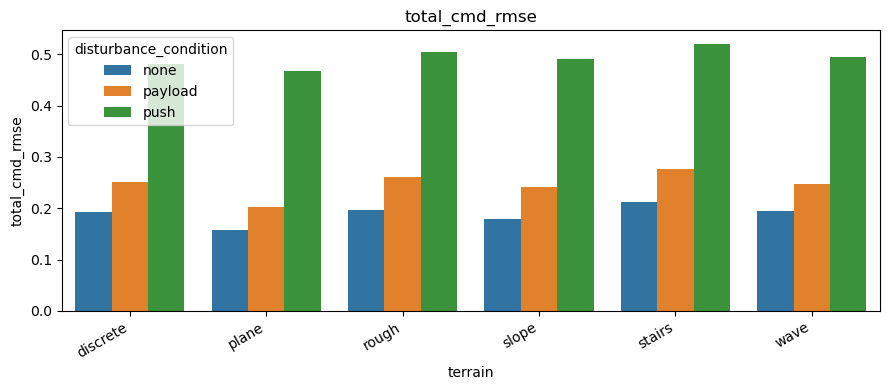

In [12]:
def plot_metric_by_terrain(results, metric, include_all=False):
    plot_df = results.copy()
    if not include_all:
        plot_df = plot_df[plot_df["terrain"] != "ALL"]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(9, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="disturbance_condition")
    else:
        for condition, group in plot_df.groupby("disturbance_condition"):
            plt.bar(group["terrain"], group[metric], label=condition)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric_by_terrain(combined_results, "total_cmd_rmse")


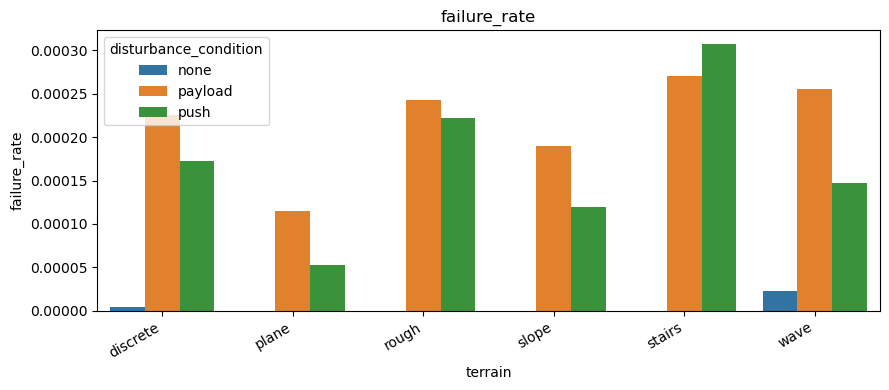

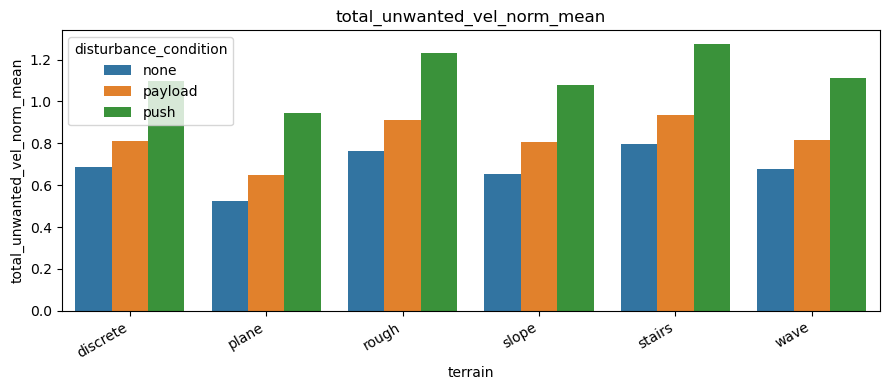

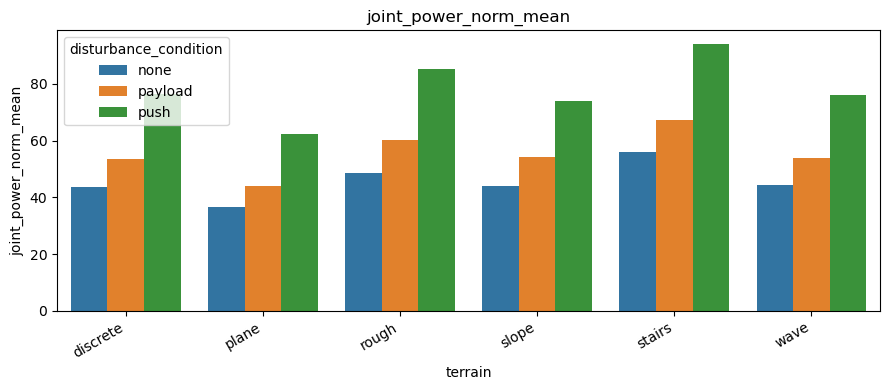

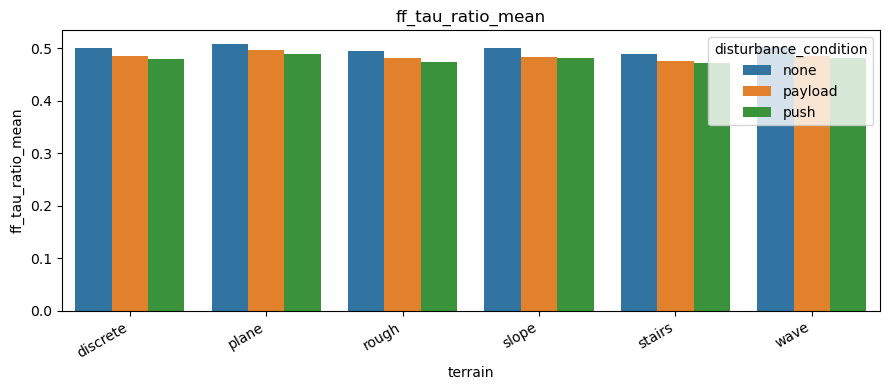

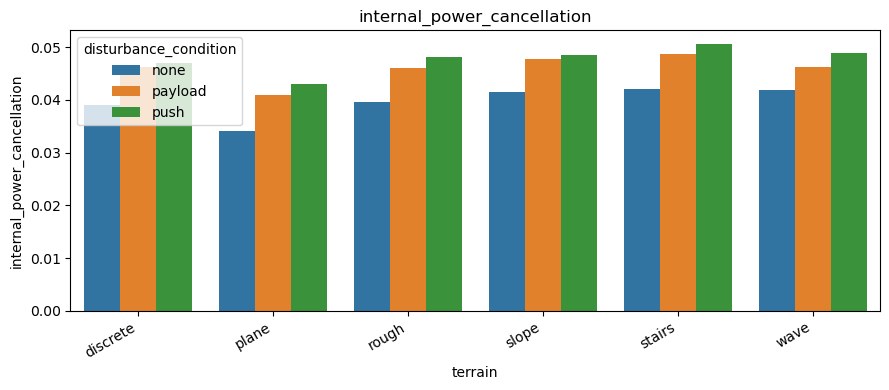

In [13]:
# Example additional plots
for metric in [
    "failure_rate",
    "total_unwanted_vel_norm_mean",
    "joint_power_norm_mean",
    "ff_tau_ratio_mean",
    "internal_power_cancellation",
]:
    if metric in combined_results.columns:
        plot_metric_by_terrain(combined_results, metric)


## Optional: compare multiple approaches

If you want to compare several approaches under the same experiment folder, set `APPROACHES` below and run the cell. It reuses the same functions above.


In [14]:
APPROACHES = ["pact"]  # e.g., ["pact", "pos", "tau"]

all_approach_dfs = []
for approach in APPROACHES:
    ft = find_eval_files(
        EXP_FOLDER,
        approach,
        disturbance_condition=DISTURBANCE_CONDITION,
    )
    if len(ft) == 0:
        print(f"No files found for approach: {approach}")
        continue

    all_approach_dfs.append(load_eval_dataset(ft))

if all_approach_dfs:
    df_multi = pd.concat(all_approach_dfs, ignore_index=True)

    multi_per_terrain = summarize_by_terrain(df_multi)
    multi_all_terrain = summarize_all_terrains(df_multi)
    multi_results = pd.concat([multi_per_terrain, multi_all_terrain], ignore_index=True)

    display(multi_results[[c for c in available_summary_cols if c in multi_results.columns]].round(4))
else:
    print("No approach files loaded.")


No files found for approach: pact
No approach files loaded.


In [15]:
def plot_metric_by_approach_and_terrain(results, metric, terrain_filter=None):
    plot_df = results.copy()

    if terrain_filter is not None:
        plot_df = plot_df[plot_df["terrain"].isin(terrain_filter)]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="approach")
    else:
        for approach, group in plot_df.groupby("approach"):
            plt.bar(group["terrain"], group[metric], label=approach)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if "multi_results" in globals():
    plot_metric_by_approach_and_terrain(multi_results, "total_cmd_rmse")
